# Figure 5

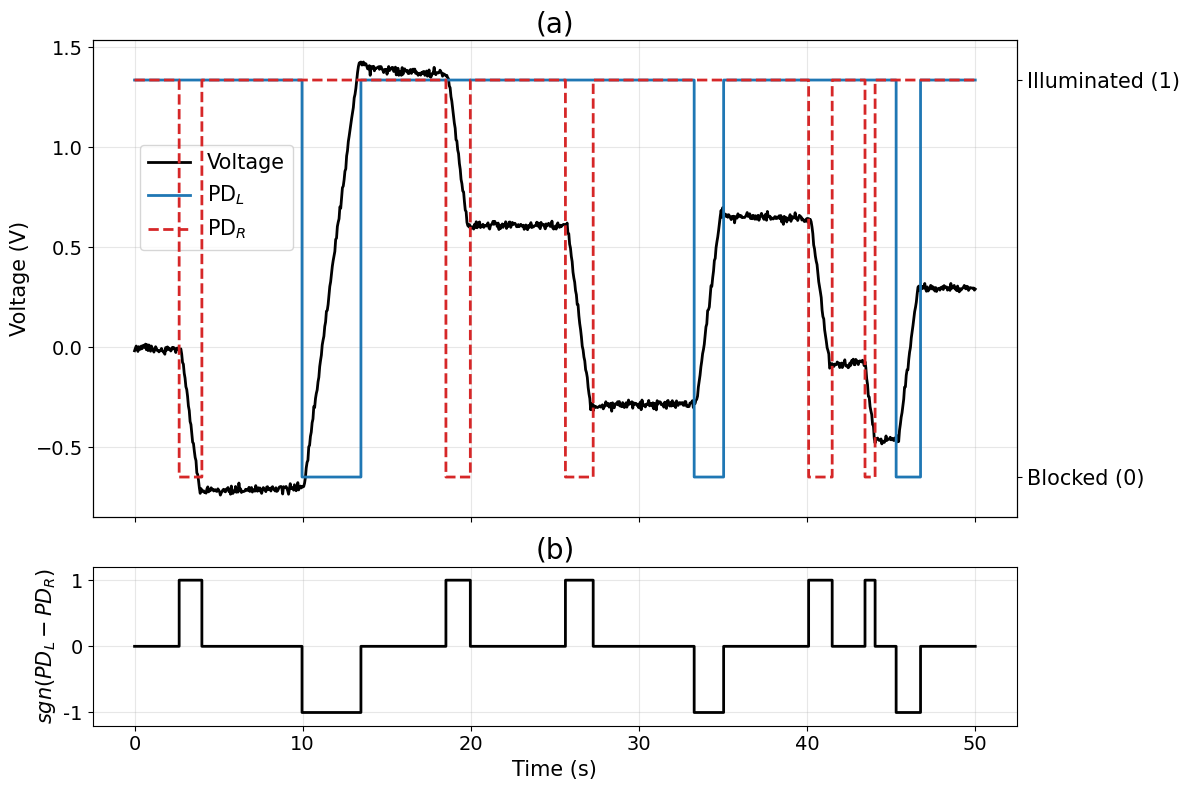

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =============================================================================
# Load data
# =============================================================================

csv_file = "./../raw-data/fig5.csv"

df = pd.read_csv(csv_file)

voltage = df["CH1V"].to_numpy()

# Ignore recorded timestamps and assume entire dataset spans 50 seconds
t = np.linspace(0, 50, len(voltage))

# =============================================================================
# Infer detector states from voltage slope
# =============================================================================

# Smooth slightly to suppress noise before differentiation
voltage_smooth = gaussian_filter1d(voltage, sigma=10)

# Voltage slope
dvdt = np.gradient(voltage_smooth, t)

# Threshold for detecting meaningful rises/decays
threshold = 25e-2

# Detector illumination states
#
# 1 = Rx Light
# 0 = Blocked
#
# Rising voltage  -> PD_L blocked
# Falling voltage -> PD_R blocked

PD_L = np.ones_like(voltage)
PD_R = np.ones_like(voltage)

PD_L[dvdt > threshold] = 0
PD_R[dvdt < -threshold] = 0

# =============================================================================
# Differential normalized illumination
# =============================================================================

delta_I = PD_L - PD_R

# =============================================================================
# Plot
# =============================================================================

axes_label_fontsize = 15
legend_fontsize = 15

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# =============================================================================
# Top subplot: Voltage + Detector States
# =============================================================================

ax1 = axes[0]

# Voltage trace
ax1.plot(
    t,
    voltage,
    color="black",
    linewidth=2,
    label="Voltage"
)

ax1.set_ylabel("Voltage (V)", fontsize = axes_label_fontsize)
ax1.set_title("(a)")
ax1.grid(True, alpha=0.3)

# Secondary axis for detector states
ax2 = ax1.twinx()



ax2.step(
    t,
    PD_L,
    where="post",
    color="tab:blue",
    linestyle="-",
    linewidth=2,
    alpha=1,
    label=r"$\mathrm{PD}_{L}$"
)

ax2.step(
    t,
    PD_R,
    where="post",
    color="tab:red",
    linestyle="--",
    linewidth=2,
    alpha=1,
    label=r"$\mathrm{PD}_{R}$"
)

ax2.set_ylim(-0.1, 1.1)

ax2.set_yticks([0, 1])
ax2.set_yticklabels([
    "Blocked (0)",
    "Illuminated (1)",
], fontsize = axes_label_fontsize)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Position legend on left side around 0.75 V
ymin, ymax = ax1.get_ylim()
legend_y = (0.75 - ymin) / (ymax - ymin)


ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center left",
    bbox_to_anchor=(0.04, legend_y),
    framealpha=0.8,
    fontsize = legend_fontsize,
)

# =============================================================================
# Bottom subplot
# =============================================================================

axes[1].step(
    t,
    delta_I,
    where="post",
    color="black",
    linewidth=2
)

axes[1].set_ylim(-1.2, 1.2)

axes[1].set_yticks([-1, 0, 1])

axes[1].set_yticklabels([
    "-1",
    "0",
    "1"
])

axes[1].set_ylabel("$sgn(PD_L - PD_R)$", fontsize = axes_label_fontsize)
axes[1].set_xlabel("Time (s)", fontsize = axes_label_fontsize)
axes[1].grid(True, alpha=0.3)

ax1.set_title("(a)", fontsize = 20)
axes[1].set_title("(b)", fontsize = 20)

ax1.tick_params(axis='both', which='major', labelsize=14)
axes[1].tick_params(axis='both', which='major', labelsize=14)


# =============================================================================
# Formatting
# =============================================================================

plt.tight_layout()
plt.savefig("fig5.pdf", dpi=300, bbox_inches="tight")

# Figure 6

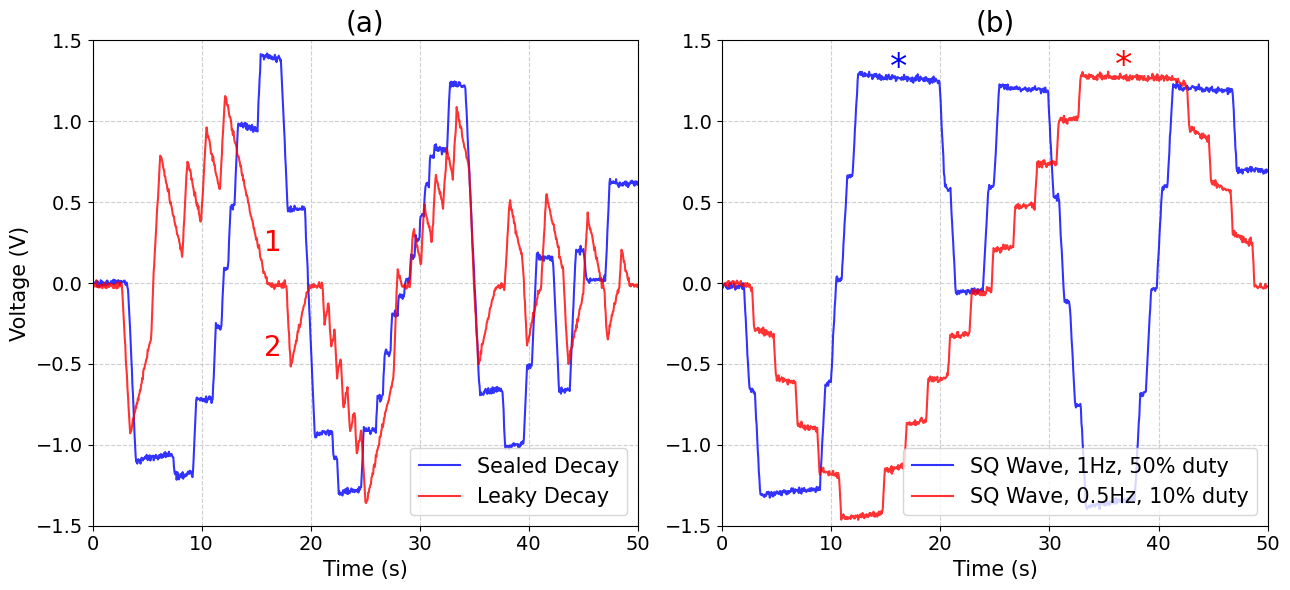

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 1. Load the datasets
df_sealed = pd.read_csv("./../raw-data/fig6a-sealed.csv")
df_leaky = pd.read_csv("./../raw-data/fig6a-leaky.csv")

df_sqwave_1Hz = pd.read_csv("./../raw-data/fig6b-1Hz.csv")
df_sqwave_500mHz = pd.read_csv("./../raw-data/fig6b-500mHz.csv")

# 2. Extract voltage data from the 'CH1V' column
voltage_sealed = df_sealed["CH1V"]
voltage_leaky = df_leaky["CH1V"]

sqwave_1Hz = df_sqwave_1Hz["CH1V"]
sqwave_500mHz = df_sqwave_500mHz["CH1V"]

# 3. Create the time axes from 0 to 50 seconds based on data points
time_sealed = np.linspace(0, 50, len(voltage_sealed))
time_leaky = np.linspace(0, 50, len(voltage_leaky))

# 4. Plotting
fig, axs = plt.subplots(1,2,figsize=(13, 6))

axs[0].plot(time_sealed, voltage_sealed, label="Sealed Decay", color="blue", alpha=0.8)
axs[0].plot(time_leaky, voltage_leaky, label="Leaky Decay", color="red", alpha=0.8)
axs[0].set_xlabel("Time (s)", fontsize=15)
axs[0].set_ylabel("Voltage (V)", fontsize=15)
axs[0].set_xlim(0, 50)
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].legend(fontsize=15, framealpha = 0.8)
axs[0].set_ylim(-1.5, 1.5)
axs[0].set_title("(a)", fontsize = 20)


axs[1].plot(time_sealed, sqwave_1Hz, label="SQ Wave, 1Hz, 50% duty", color="blue", alpha=0.8)
axs[1].plot(time_leaky, sqwave_500mHz, label="SQ Wave, 0.5Hz, 10% duty", color="red", alpha=0.8)
axs[1].set_xlabel("Time (s)", fontsize=15)
# axs[1].set_ylabel("Voltage (V)", fontsize=15)
axs[1].set_xlim(0, 50)
axs[1].grid(True, linestyle="--", alpha=0.6)
axs[1].legend(fontsize=15, framealpha = 0.8)
axs[1].set_ylim(-1.5, 1.5)
axs[1].set_title("(b)", fontsize = 20)

axs[0].tick_params(axis='both', which='major', labelsize=14)
axs[1].tick_params(axis='both', which='major', labelsize=14)

axs[0].text(15.7,0.2, "1", fontsize = 20, c = 'r')
axs[0].text(15.7,-0.45, "2", fontsize = 20, c = 'r')

axs[1].text(15.4,1.27, "*", fontsize = 25, c = 'b')
axs[1].text(36,1.28, "*", fontsize = 25, c = 'r')

plt.tight_layout()
plt.savefig("fig6.pdf", dpi=300, bbox_inches="tight")